In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
import random
import time
import json
import os

from IPython.display import display
import matplotlib
matplotlib.get_backend()


'module://matplotlib_inline.backend_inline'

In [4]:
%matplotlib widget


In [5]:
import torch
import torch.nn as nn

class LinearIntegrator(nn.Module):
    def __init__(self, k=5):
        super().__init__()
        self.lin = nn.Linear(k * 3, 1)

    def forward(self, x):
        return self.lin(x).squeeze(-1)


class MLPIntegrator(nn.Module):
    def __init__(self, k=5, hidden=128, num_layers=3):
        super().__init__()
        in_dim = k * 3

        layers = [nn.Linear(in_dim, hidden), nn.ReLU()]

        for _ in range(num_layers - 2):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]

        layers.append(nn.Linear(hidden, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def load_integrator_model(path, device="cuda"):
    """
    Load a trained linear or MLP integrator saved in the Square format.
    """
    device = torch.device(device)

    ckpt = torch.load(path, map_location=device)

    model_type = ckpt["model_type"]
    cfg = ckpt["config"]

    if model_type == "linear":
        model = LinearIntegrator(k=cfg["k"])

    elif model_type == "mlp":
        model = MLPIntegrator(
            k=cfg["k"],
            hidden=cfg["hidden"],
            num_layers=cfg["num_layers"],
        )

    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    model.load_state_dict(ckpt["state_dict"])
    model = model.to(device).eval()

    print(f"Loaded {model_type} integrator")
    print(f"  k       = {cfg['k']}")
    print(f"  R       = {cfg['R']}")
    print(f"  u_scale = {cfg['u_scale']:.6e}")

    return model, cfg




In [6]:
def build_bc_mask(Nt, Nx):
    is_bc = np.zeros((Nt, Nx), dtype=bool)
    is_bc[:, 0] = True
    is_bc[:, Nx-1] = True
    return is_bc

def activate_bc_from_squares(visited, is_bc, R):
    """
    Activate BC points only if they lie inside a square
    of radius R around any visited *interior* point.
    """
    Nt, Nx = visited.shape
    interior = np.argwhere(visited & (~is_bc))

    for (t0, x0) in interior:
        t_min = max(0, t0 - R)
        t_max = min(Nt - 1, t0 + R)
        x_min = max(0, x0 - R)
        x_max = min(Nx - 1, x0 + R)

        for t in range(t_min, t_max + 1):
            for x in range(x_min, x_max + 1):
                if is_bc[t, x]:
                    visited[t, x] = True


In [7]:
def build_features_for_model(neigh, sampled, u_values, u_scale):
    """
    Build Scheme-B features from already-selected neighbors.

    neigh: list or array of shape (k, 2) with (tn, xn)
    sampled: (t0, x0)
    u_values: dict {(t, x): u}
    u_scale: float (same as training)

    returns:
        feats: np.ndarray shape (k*3,)
    """
    t0, x0 = sampled
    feats = []

    for (tn, xn) in neigh:
        dt = t0 - tn          # NO scaling
        dx = x0 - xn          # NO scaling
        u  = u_values[(int(tn), int(xn))] / u_scale
        feats.append([dt, dx, u])

    return np.array(feats, dtype=np.float32).reshape(-1)


In [8]:
try:
    import mplcursors

    def visualize_rollout_interactive_simple(
        visited,
        u_values,
        history,
        ground_truth_data,
        config=None,
    ):
        """
        Simple interactive visualization using mplcursors.
        Hover shows error, prediction, neighbors, etc.
        """
        Nt, Nx = visited.shape

        fig, ax = plt.subplots(figsize=(12, 8))

        visited_pts = np.array(list(u_values.keys()))
        history_dict = {tuple(h['sampled']): h for h in history}

        ic_bc_pts = []
        pred_pts = []
        pred_vals = []

        for pt in visited_pts:
            pt = tuple(pt)
            if pt in history_dict:
                pred_pts.append(pt)
                pred_vals.append(u_values[pt])
            else:
                ic_bc_pts.append(pt)

        # ---- IC / BC ----
        if ic_bc_pts:
            arr = np.array(ic_bc_pts)
            ax.scatter(
                arr[:,1], arr[:,0],
                s=20, c="gray", alpha=0.5,
                label="IC / BC", zorder=1
            )

        # ---- Predicted interior ----
        if pred_pts:
            pts = np.array(pred_pts)
            vals = np.array(pred_vals)

            scatter = ax.scatter(
                pts[:,1], pts[:,0],
                c=vals, s=40,
                cmap="viridis",
                edgecolors="black",
                linewidth=0.5,
                alpha=0.8,
                label="Predicted",
                zorder=2,
            )
            plt.colorbar(scatter, ax=ax, label="Predicted u")

            cursor = mplcursors.cursor(scatter, hover=True)

            @cursor.connect("add")
            def on_add(sel):
                idx = sel.index
                pt = tuple(pts[idx])
                h = history_dict.get(pt)
                if h:
                    pred = h["prediction"]
                    true = h["ground_truth"]
                    err = pred - true
                    neigh = h["neighbors"]
                    sel.annotation.set_text(
                        f"Point: {pt}\n"
                        f"Pred: {pred:.4f}\n"
                        f"True: {true:.4f}\n"
                        f"Error: {err:.4f}\n"
                        f"Neighbors: {len(neigh)}"
                    )

        ax.set_xlabel("x")
        ax.set_ylabel("t")
        ax.set_title("Rollout predictions (hover for details)")
        ax.legend()
        plt.tight_layout()
        plt.show()

    print("mplcursors available — hover visualization enabled")

except ImportError:
    print("mplcursors not available. Install with: pip install mplcursors")


mplcursors available — hover visualization enabled


In [9]:
def visualize_rollout_simple(visited, u_values, history, ground_truth_data, R, config=None):
    """
    Simple non-interactive visualization of rollout results.
    """
    Nt, Nx = visited.shape

    fig, ax = plt.subplots(figsize=(12, 8))

    visited_pts = np.array(list(u_values.keys()))
    history_dict = {tuple(h['sampled']): h for h in history}

    ic_bc_pts = []
    pred_pts = []
    pred_vals = []

    for pt in visited_pts:
        pt_t = tuple(pt)
        if pt_t in history_dict:
            pred_pts.append(pt_t)
            pred_vals.append(u_values[pt_t])
        else:
            ic_bc_pts.append(pt_t)

    print(f"Plotting: {len(ic_bc_pts)} IC/BC points, {len(pred_pts)} predicted points")

    # ---- IC + BC points ----
    if len(ic_bc_pts) > 0:
        ic_bc_arr = np.array(ic_bc_pts)
        ax.scatter(
            ic_bc_arr[:,1], ic_bc_arr[:,0],
            s=20, c='gray', alpha=0.5,
            label='IC/BC', zorder=1
        )

    # ---- Predicted points ----
    if len(pred_pts) > 0:
        pred_pts_arr = np.array(pred_pts)
        pred_vals_arr = np.array(pred_vals)

        scatter = ax.scatter(
            pred_pts_arr[:,1], pred_pts_arr[:,0],
            c=pred_vals_arr, s=40,
            cmap='viridis', alpha=0.8,
            edgecolors='black', linewidth=0.5,
            label='Predicted', zorder=2
        )
        plt.colorbar(scatter, ax=ax, label='Predicted u value')
    else:
        ax.text(
            0.5, 0.5,
            'No predicted interior points to display',
            transform=ax.transAxes,
            ha='center', va='center', fontsize=14
        )

    ax.set_xlabel('x (space)')
    ax.set_ylabel('t (time)')
    ax.set_title('Rollout Results — Predicted Interior Points')
    ax.set_aspect('auto')

    if len(pred_pts) > 0 or len(ic_bc_pts) > 0:
        ax.legend()

    plt.tight_layout()

    # For Jupyter
    display(fig)

    print(f"\n✓ Displayed {len(pred_pts)} predicted points and {len(ic_bc_pts)} IC/BC points")

    return fig, ax


In [10]:
import pickle

_ROLLOUT_CACHE = "rollout_results_wave.pkl"

def save_rollout_results(
    path=None,
    visited_mlp=None,
    u_mlp=None,
    hist_mlp=None,
    visited_lin=None,
    u_lin=None,
    hist_lin=None,
    data=None,
    cfg_mlp=None,
    metrics_mlp=None,
    metrics_lin=None,
):
    """Save rollout results so you can load later and run visualization without re-running rollouts."""
    path = path or _ROLLOUT_CACHE
    payload = {
        "visited_mlp": visited_mlp,
        "u_mlp": u_mlp,
        "hist_mlp": hist_mlp,
        "visited_lin": visited_lin,
        "u_lin": u_lin,
        "hist_lin": hist_lin,
        "data": data,
        "cfg_mlp": cfg_mlp,
        "metrics_mlp": metrics_mlp,
        "metrics_lin": metrics_lin,
    }
    with open(path, "wb") as f:
        pickle.dump(payload, f)
    print(f"Saved rollout results to {path}")

def load_rollout_results(path=None):
    """Load previously saved rollout results. Returns dict with keys:
    visited_mlp, u_mlp, hist_mlp, visited_lin, u_lin, hist_lin, data, cfg_mlp, metrics_mlp, metrics_lin.
    """
    path = path or _ROLLOUT_CACHE
    with open(path, "rb") as f:
        out = pickle.load(f)
    print(f"Loaded rollout results from {path}")
    return out


In [11]:
def candidates_from_interior_squares(visited, is_bc, R):
    """
    Generate candidate points (unvisited) within a square
    of radius R around any visited interior point.
    
    visited: bool (Nt, Nx)
    is_bc: bool (Nt, Nx)
    R: integer radius in index space
    """
    Nt, Nx = visited.shape
    interior = np.argwhere(visited & (~is_bc))
    cand = set()
    
    for (t0, x0) in interior:
        t_min = max(0, t0 - R)
        t_max = min(Nt - 1, t0 + R)
        x_min = max(0, x0 - R)
        x_max = min(Nx - 1, x0 + R)
        
        for t in range(t_min, t_max + 1):
            for x in range(x_min, x_max + 1):
                if not visited[t, x]:
                    cand.add((t, x))
    
    return list(cand)


def rollout_with_model_square(
    model,
    ground_truth_data,
    k,
    Rmax,
    u_scale,
    max_iterations=10000,
    device="cuda",
    seed=0,
):
    """
    Square-based Scheme-B rollout with new strategy:
    - Generate candidates from squares around visited interior points
    - Find neighbors by expanding square until we get k neighbors (max Rmax)
    - Add new candidates from square around newly predicted point
    
    max_iterations: Maximum number of interior points to predict (default: 10000)
    """
    # ---- seeding ----
    random.seed(seed)
    np.random.seed(seed)

    device = torch.device(device)

    ground_truth_data = np.asarray(ground_truth_data, dtype=np.float32)
    Nt, Nx = ground_truth_data.shape

    model = model.to(device).eval()

    visited = np.zeros((Nt, Nx), dtype=bool)
    is_bc = build_bc_mask(Nt, Nx)

    # ---- IC and BC ----
    visited[0, :] = True  # IC
    visited[:, 0] = True  # BC left
    visited[:, Nx - 1] = True  # BC right
    
    # Initialize u_values with IC and BC (ground truth values)
    u_values = {}
    for x in range(Nx):
        u_values[(0, x)] = float(ground_truth_data[0, x])  # IC
    for t in range(Nt):
        u_values[(t, 0)] = float(ground_truth_data[t, 0])  # BC left
        u_values[(t, Nx - 1)] = float(ground_truth_data[t, Nx - 1])  # BC right

    history = []
    total_interior = Nt * (Nx - 2)

    def find_neighbors(t0, x0):
        """
        Find k neighbors by expanding square from small to large.
        Start with small square, check for visited points, expand until we get k neighbors.
        Only return neighbors that are in u_values.
        Returns: (neighbors_list, square_radius_used)
        """
        for r in range(1, Rmax + 1):
            neigh = []
            t_min = max(0, t0 - r)
            t_max = min(Nt - 1, t0 + r)
            x_min = max(0, x0 - r)
            x_max = min(Nx - 1, x0 + r)
            
            # Collect visited points in this square that are in u_values
            for t in range(t_min, t_max + 1):
                for x in range(x_min, x_max + 1):
                    if visited[t, x] and (t, x) in u_values:
                        neigh.append((t, x))
            
            # If we have enough neighbors, return first k and the square radius used
            if len(neigh) >= k:
                return (neigh[:k], r)
        
        # No neighbors found even at max radius
        return (None, None)

    # Iterate for exactly max_iterations (or until no more candidates)
    for it in range(max_iterations):
        # Generate candidates from squares around visited interior points
        candidates = candidates_from_interior_squares(visited, is_bc, Rmax)
        
        # Filter to only interior candidates
        candidates = [(t, x) for (t, x) in candidates if not is_bc[t, x] and not visited[t, x]]
        
        if len(candidates) == 0:
            print(f"Stopping rollout at iteration {it}: no more candidates.")
            break
        
        # ---- progress ----
        if (it + 1) % 50 == 0 or it == 0:
            visited_interior = np.logical_and(visited, ~is_bc).sum()
            coverage = 100.0 * visited_interior / total_interior
            print(
                f"[rollout] iteration {it+1:5d}/{max_iterations}"
                + f" | coverage = {coverage:6.3f}% | candidates = {len(candidates)}"
            )

        # ---- randomly sample candidate ----
        t0, x0 = random.choice(candidates)

        # Find neighbors - try multiple candidates if needed
        max_tries = 100
        neigh = None
        square_radius = None
        for _ in range(max_tries):
            neigh, square_radius = find_neighbors(t0, x0)
            if neigh is not None and len(neigh) >= k:
                break
            # Try a different candidate
            if len(candidates) > 1:
                t0, x0 = random.choice(candidates)
        
        if neigh is None or len(neigh) < k:
            # Skip this iteration if we can't find neighbors
            continue

        feats = build_features_for_model(
            neigh,
            (t0, x0),
            u_values,
            u_scale,
        )

        with torch.no_grad():
            pred = model(
                torch.from_numpy(feats).to(device).unsqueeze(0)
            ).item()

        true = float(ground_truth_data[t0, x0])

        visited[t0, x0] = True
        u_values[(t0, x0)] = pred

        history.append({
            "sampled": [t0, x0],
            "neighbors": neigh,
            "square_radius": square_radius,  # Store the square radius used
            "prediction": pred,
            "ground_truth": true,
        })

        # ---- activate BCs only if touched by squares ----
        activate_bc_from_squares(visited, is_bc, Rmax)

    # ---- metrics ----
    errors = np.array([h["prediction"] - h["ground_truth"] for h in history])
    mse = float(np.mean(errors**2)) if len(errors) else np.nan
    rmse = float(np.sqrt(mse)) if len(errors) else np.nan

    visited_interior = np.logical_and(visited, ~is_bc)

    metrics = {
        "iterations": len(history),
        "coverage": visited_interior.sum() / total_interior,
        "mse": mse,
        "rmse": rmse,
    }

    return visited, u_values, history, metrics


In [12]:
# Generate ground truth data (wave equation, same format as training)
def wave_solver_dirichlet(u0, ut0, c=1.0, dx=1/128, dt=1e-4, n_steps=2000):
    Nx = len(u0)
    u = u0.copy()
    u_prev = u0.copy()

    # first step using initial velocity
    u_new = u.copy()
    for i in range(1, Nx - 1):
        lap = (u[i+1] - 2*u[i] + u[i-1]) / dx**2
        u_new[i] = u[i] + dt * ut0[i] + 0.5 * c**2 * dt**2 * lap

    u_prev = u.copy()
    u = u_new.copy()
    traj = [u_prev.copy(), u.copy()]

    for _ in range(n_steps - 1):
        u_new = u.copy()
        for i in range(1, Nx - 1):
            lap = (u[i+1] - 2*u[i] + u[i-1]) / dx**2
            u_new[i] = 2*u[i] - u_prev[i] + c**2 * dt**2 * lap

        u_new[0] = 0.0
        u_new[-1] = 0.0

        u_prev = u.copy()
        u = u_new.copy()
        traj.append(u.copy())

    return np.stack(traj)


def generate_wave_data(Nx=500, c=1.0, dt=1e-4, n_steps=20000):
    dx = 1.0 / (Nx - 1)
    x = np.linspace(0, 1, Nx)

    u0 = np.sin(2 * np.pi * x)
    ut0 = np.zeros_like(x)

    data = wave_solver_dirichlet(u0, ut0, c, dx, dt, n_steps)
    return x, data


x, data = generate_wave_data(
    Nx=500,
    c=1.0,
    dt=1e-4,
    n_steps=20000,
)

print(f"Data shape: {data.shape}")


Data shape: (20001, 500)


In [ ]:
device = "cuda"

# ======================
# MLP rollout
# ======================
model_mlp, cfg_mlp = load_integrator_model(
    "small_mlp_integrator_square.pth",
    device=device,
)

visited_mlp, u_mlp, hist_mlp, metrics_mlp = rollout_with_model_square(
    model_mlp,
    data,
    k=cfg_mlp["k"],
    Rmax=cfg_mlp["R"],
    u_scale=cfg_mlp["u_scale"],
    max_iterations=100,
    device=device,
    seed=42,
)

print("MLP metrics:", metrics_mlp)


# ======================
# Linear rollout
# ======================
model_lin, cfg_lin = load_integrator_model(
    "linear_integrator_Square.pth.pth",
    device=device,
)

visited_lin, u_lin, hist_lin, metrics_lin = rollout_with_model_square(
    model_lin,
    data,
    k=cfg_lin["k"],
    Rmax=cfg_lin["R"],
    u_scale=cfg_lin["u_scale"],
    max_iterations=100,
    device=device,
    seed=42,
)

print("Linear metrics:", metrics_lin)


C:\Users\amt35\AppData\Local\Temp\ipykernel_6248\337209653.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location=device)


FileNotFoundError: [Errno 2] No such file or directory: 'small_mlp_integrator.pth'

In [ ]:

# Save after rollouts (run this cell after the rollout cell above)
save_rollout_results(
    path=_ROLLOUT_CACHE,
    visited_mlp=visited_mlp,
    u_mlp=u_mlp,
    hist_mlp=hist_mlp,
    visited_lin=visited_lin,
    u_lin=u_lin,
    hist_lin=hist_lin,
    data=data,
    cfg_mlp=cfg_mlp,
    metrics_mlp=metrics_mlp,
    metrics_lin=metrics_lin,
)

Saved rollout results to rollout_results.pkl


C:\Users\amt35\AppData\Local\Temp\ipykernel_11260\3649486168.py:366: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


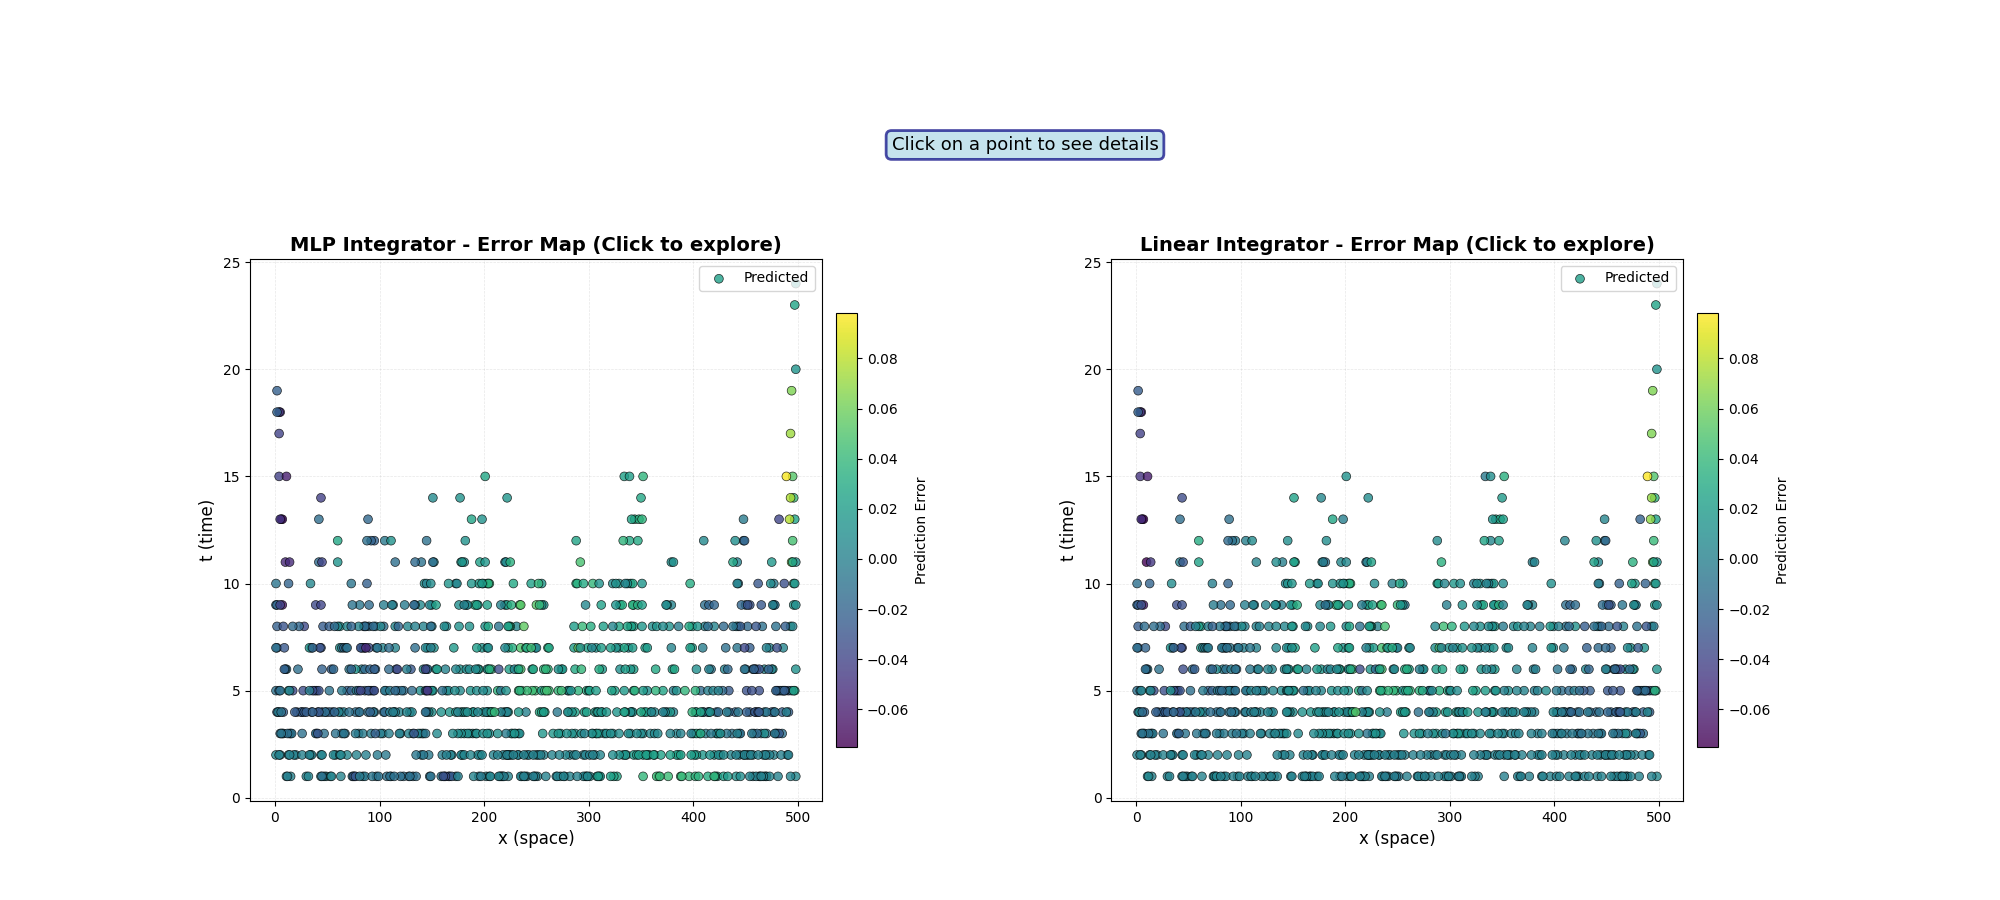


✓ Enhanced interactive comparison plot ready
  MLP:    1000 predicted points
  Linear: 1000 predicted points
  Error range: [-0.074902, 0.098057]
  Click on any point to see its neighbors and search squares!


In [ ]:
def visualize_rollout_comparison_click_interactive(
    visited_mlp, u_mlp, hist_mlp,
    visited_lin, u_lin, hist_lin,
    ground_truth_data,
    Rmax,
    config=None,
):
    """
    Enhanced interactive visualization with click-based node selection.
    - Click on a point to see it as a node
    - Edges connect to neighbors
    - Expanding squares are drawn
    - Colors represent error using viridis colormap
    - Synchronized selection between MLP and Linear
    - Shows values and errors at the top
    """
    Nt, Nx = ground_truth_data.shape
    
    fig = plt.figure(figsize=(20, 9))
    gs = fig.add_gridspec(2, 2, height_ratios=[0.12, 0.88], hspace=0.25, wspace=0.25)
    
    # Text area at the top spanning both columns
    ax_text = fig.add_subplot(gs[0, :])
    ax_text.axis('off')
    text_display = ax_text.text(0.5, 0.5, 'Click on a point to see details', 
                                ha='center', va='center', fontsize=13,
                                bbox=dict(boxstyle='round', facecolor='lightblue', 
                                         alpha=0.7, edgecolor='navy', linewidth=2))
    
    axes = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]
    
    # Process MLP data
    visited_pts_mlp = np.array(list(u_mlp.keys()))
    history_dict_mlp = {tuple(h['sampled']): h for h in hist_mlp}
    
    pred_pts_mlp = []
    pred_errors_mlp = []
    
    for pt in visited_pts_mlp:
        pt_tuple = tuple(pt)
        if pt_tuple in history_dict_mlp:
            pred_pts_mlp.append(pt_tuple)
            h = history_dict_mlp[pt_tuple]
            pred = h['prediction']
            true = h['ground_truth']
            err = pred - true
            pred_errors_mlp.append(err)
    
    # Process Linear data
    visited_pts_lin = np.array(list(u_lin.keys()))
    history_dict_lin = {tuple(h['sampled']): h for h in hist_lin}
    
    pred_pts_lin = []
    pred_errors_lin = []
    
    for pt in visited_pts_lin:
        pt_tuple = tuple(pt)
        if pt_tuple in history_dict_lin:
            pred_pts_lin.append(pt_tuple)
            h = history_dict_lin[pt_tuple]
            pred = h['prediction']
            true = h['ground_truth']
            err = pred - true
            pred_errors_lin.append(err)
    
    # Calculate error range for colormap (use actual error values)
    all_errors = pred_errors_mlp + pred_errors_lin
    if len(all_errors) > 0:
        error_min = min(all_errors)
        error_max = max(all_errors)
        vmin = error_min
        vmax = error_max
    else:
        error_min = error_max = 0.0
        vmin = vmax = 0.0
    
    # Plot MLP
    ax_mlp = axes[0]
    if len(pred_pts_mlp) > 0:
        pred_pts_arr_mlp = np.array(pred_pts_mlp)
        pred_errors_arr_mlp = np.array(pred_errors_mlp)
        
        scatter_mlp = ax_mlp.scatter(
            pred_pts_arr_mlp[:, 1], pred_pts_arr_mlp[:, 0],
            c=pred_errors_arr_mlp, s=40,
            cmap='viridis', vmin=vmin, vmax=vmax,
            alpha=0.8, edgecolors='black', linewidth=0.5,
            label='Predicted', zorder=2, picker=True
        )
        cbar_mlp = plt.colorbar(scatter_mlp, ax=ax_mlp, label='Prediction Error', 
                                location='right', pad=0.02, shrink=0.8)
        
        # Store references for click handler
        ax_mlp._scatter = scatter_mlp
        ax_mlp._history_dict = history_dict_mlp
        ax_mlp._pred_pts_arr = pred_pts_arr_mlp
        ax_mlp._Rmax = Rmax
        ax_mlp._Nt = Nt
        ax_mlp._Nx = Nx
        ax_mlp._ground_truth_data = ground_truth_data
    
    # Plot Linear
    ax_lin = axes[1]
    if len(pred_pts_lin) > 0:
        pred_pts_arr_lin = np.array(pred_pts_lin)
        pred_errors_arr_lin = np.array(pred_errors_lin)
        
        scatter_lin = ax_lin.scatter(
            pred_pts_arr_lin[:, 1], pred_pts_arr_lin[:, 0],
            c=pred_errors_arr_lin, s=40,
            cmap='viridis', vmin=vmin, vmax=vmax,
            alpha=0.8, edgecolors='black', linewidth=0.5,
            label='Predicted', zorder=2, picker=True
        )
        cbar_lin = plt.colorbar(scatter_lin, ax=ax_lin, label='Prediction Error',
                                location='right', pad=0.02, shrink=0.8)
        
        # Store references for click handler
        ax_lin._scatter = scatter_lin
        ax_lin._history_dict = history_dict_lin
        ax_lin._pred_pts_arr = pred_pts_arr_lin
        ax_lin._Rmax = Rmax
        ax_lin._Nt = Nt
        ax_lin._Nx = Nx
        ax_lin._ground_truth_data = ground_truth_data
    
    # Shared function to highlight a point in both plots
    def highlight_point(pt, source_ax):
        """Highlight the same point in both MLP and Linear plots"""
        t0, x0 = pt
        
        # Clear previous annotations in both axes
        for ax in [ax_mlp, ax_lin]:
            for artist in list(ax.lines) + list(ax.patches) + list(ax.collections):
                if hasattr(artist, '_interactive'):
                    artist.remove()
        
        # Check if point exists in both models
        h_mlp = history_dict_mlp.get(pt, None)
        h_lin = history_dict_lin.get(pt, None)
        
        if h_mlp is None and h_lin is None:
            return
        
        # Get ground truth value
        true_val = ground_truth_data[t0, x0]
        
        # Process MLP
        if h_mlp is not None:
            neighbors_mlp = h_mlp['neighbors']
            square_radius_mlp = h_mlp.get('square_radius', Rmax)
            pred_mlp = h_mlp['prediction']
            err_mlp = pred_mlp - true_val
            pct_err_mlp = (err_mlp / abs(true_val) * 100) if true_val != 0 else 0
            
            # Draw expanding squares
            for r in range(1, square_radius_mlp + 1):
                t_min = max(0, t0 - r)
                t_max = min(Nt - 1, t0 + r)
                x_min = max(0, x0 - r)
                x_max = min(Nx - 1, x0 + r)
                
                width = (x_max - x_min + 1)
                height = (t_max - t_min + 1)
                
                rect = patches.Rectangle(
                    (x_min - 0.5, t_min - 0.5), width, height,
                    linewidth=1.5 if r == square_radius_mlp else 0.5,
                    edgecolor='red' if r == square_radius_mlp else 'orange',
                    facecolor='none',
                    alpha=0.3 if r == square_radius_mlp else 0.1,
                    zorder=1
                )
                rect._interactive = True
                ax_mlp.add_patch(rect)
            
            # Draw edges to neighbors
            for neigh in neighbors_mlp:
                tn, xn = neigh
                line = ax_mlp.plot([x0, xn], [t0, tn], 
                                  'b-', linewidth=1.5, alpha=0.6, zorder=3)[0]
                line._interactive = True
            
            # Highlight clicked point
            node = ax_mlp.scatter([x0], [t0], s=200, c='red', 
                                edgecolors='black', linewidth=2, 
                                marker='o', zorder=5)
            node._interactive = True
            
            # Highlight neighbors
            if len(neighbors_mlp) > 0:
                neigh_arr = np.array(neighbors_mlp)
                neigh_nodes = ax_mlp.scatter(neigh_arr[:, 1], neigh_arr[:, 0], 
                                            s=100, c='blue',
                                            edgecolors='black', linewidth=1.5,
                                            marker='s', zorder=4, alpha=0.8)
                neigh_nodes._interactive = True
        else:
            pred_mlp = None
            err_mlp = None
            pct_err_mlp = None
        
        # Process Linear
        if h_lin is not None:
            neighbors_lin = h_lin['neighbors']
            square_radius_lin = h_lin.get('square_radius', Rmax)
            pred_lin = h_lin['prediction']
            err_lin = pred_lin - true_val
            pct_err_lin = (err_lin / abs(true_val) * 100) if true_val != 0 else 0
            
            # Draw expanding squares
            for r in range(1, square_radius_lin + 1):
                t_min = max(0, t0 - r)
                t_max = min(Nt - 1, t0 + r)
                x_min = max(0, x0 - r)
                x_max = min(Nx - 1, x0 + r)
                
                width = (x_max - x_min + 1)
                height = (t_max - t_min + 1)
                
                rect = patches.Rectangle(
                    (x_min - 0.5, t_min - 0.5), width, height,
                    linewidth=1.5 if r == square_radius_lin else 0.5,
                    edgecolor='red' if r == square_radius_lin else 'orange',
                    facecolor='none',
                    alpha=0.3 if r == square_radius_lin else 0.1,
                    zorder=1
                )
                rect._interactive = True
                ax_lin.add_patch(rect)
            
            # Draw edges to neighbors
            for neigh in neighbors_lin:
                tn, xn = neigh
                line = ax_lin.plot([x0, xn], [t0, tn], 
                                  'b-', linewidth=1.5, alpha=0.6, zorder=3)[0]
                line._interactive = True
            
            # Highlight clicked point
            node = ax_lin.scatter([x0], [t0], s=200, c='red', 
                                edgecolors='black', linewidth=2, 
                                marker='o', zorder=5)
            node._interactive = True
            
            # Highlight neighbors
            if len(neighbors_lin) > 0:
                neigh_arr = np.array(neighbors_lin)
                neigh_nodes = ax_lin.scatter(neigh_arr[:, 1], neigh_arr[:, 0], 
                                            s=100, c='blue',
                                            edgecolors='black', linewidth=1.5,
                                            marker='s', zorder=4, alpha=0.8)
                neigh_nodes._interactive = True
        else:
            pred_lin = None
            err_lin = None
            pct_err_lin = None
        
        # Update text display with better formatting
        if h_mlp is not None and h_lin is not None:
            text_str = (f"Point: ({t0}, {x0})  |  True Value: {true_val:.6f}\n"
                       f"MLP:    Predicted: {pred_mlp:.6f}  |  Error: {err_mlp:+.6f}  |  % Error: {pct_err_mlp:+.4f}%\n"
                       f"Linear: Predicted: {pred_lin:.6f}  |  Error: {err_lin:+.6f}  |  % Error: {pct_err_lin:+.4f}%")
        elif h_mlp is not None:
            text_str = (f"Point: ({t0}, {x0})  |  True Value: {true_val:.6f}\n"
                       f"MLP:    Predicted: {pred_mlp:.6f}  |  Error: {err_mlp:+.6f}  |  % Error: {pct_err_mlp:+.4f}%\n"
                       f"Linear: Not available at this point")
        elif h_lin is not None:
            text_str = (f"Point: ({t0}, {x0})  |  True Value: {true_val:.6f}\n"
                       f"MLP:    Not available at this point\n"
                       f"Linear: Predicted: {pred_lin:.6f}  |  Error: {err_lin:+.6f}  |  % Error: {pct_err_lin:+.4f}%")
        else:
            text_str = f"Point: ({t0}, {x0})  |  Not available in either model"
        
        text_display.set_text(text_str)
        
        fig.canvas.draw()
    
    # Click handler for MLP
    def on_click_mlp(event):
        if event.inaxes != ax_mlp:
            return
        if event.button != 1:  # Only left click
            return
        
        # Find nearest point
        x_click, y_click = event.xdata, event.ydata
        if x_click is None or y_click is None:
            return
        
        distances = np.sqrt((pred_pts_arr_mlp[:, 1] - x_click)**2 + 
                           (pred_pts_arr_mlp[:, 0] - y_click)**2)
        nearest_idx = np.argmin(distances)
        min_distance = distances[nearest_idx]
        
        # Only proceed if click is close enough to a point (threshold: 2% of plot range)
        x_range = ax_mlp.get_xlim()[1] - ax_mlp.get_xlim()[0]
        y_range = ax_mlp.get_ylim()[1] - ax_mlp.get_ylim()[0]
        threshold = max(x_range, y_range) * 0.02
        
        if min_distance > threshold:
            return  # Click too far from any point
        
        pt = tuple(pred_pts_arr_mlp[nearest_idx])
        
        # Highlight in both plots
        highlight_point(pt, ax_mlp)
    
    # Click handler for Linear
    def on_click_lin(event):
        if event.inaxes != ax_lin:
            return
        if event.button != 1:  # Only left click
            return
        
        # Find nearest point
        x_click, y_click = event.xdata, event.ydata
        if x_click is None or y_click is None:
            return
        
        distances = np.sqrt((pred_pts_arr_lin[:, 1] - x_click)**2 + 
                           (pred_pts_arr_lin[:, 0] - y_click)**2)
        nearest_idx = np.argmin(distances)
        min_distance = distances[nearest_idx]
        
        # Only proceed if click is close enough to a point (threshold: 2% of plot range)
        x_range = ax_lin.get_xlim()[1] - ax_lin.get_xlim()[0]
        y_range = ax_lin.get_ylim()[1] - ax_lin.get_ylim()[0]
        threshold = max(x_range, y_range) * 0.02
        
        if min_distance > threshold:
            return  # Click too far from any point
        
        pt = tuple(pred_pts_arr_lin[nearest_idx])
        
        # Highlight in both plots
        highlight_point(pt, ax_lin)
    
    # Connect click handlers
    if len(pred_pts_mlp) > 0:
        fig.canvas.mpl_connect('button_press_event', on_click_mlp)
    if len(pred_pts_lin) > 0:
        fig.canvas.mpl_connect('button_press_event', on_click_lin)
    
    ax_mlp.set_xlabel('x (space)', fontsize=12)
    ax_mlp.set_ylabel('t (time)', fontsize=12)
    ax_mlp.set_title('MLP Integrator - Error Map (Click to explore)', fontsize=14, fontweight='bold')
    ax_mlp.set_aspect('auto')
    ax_mlp.legend(fontsize=10, loc='upper right')
    ax_mlp.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax_mlp.tick_params(labelsize=10)
    
    ax_lin.set_xlabel('x (space)', fontsize=12)
    ax_lin.set_ylabel('t (time)', fontsize=12)
    ax_lin.set_title('Linear Integrator - Error Map (Click to explore)', fontsize=14, fontweight='bold')
    ax_lin.set_aspect('auto')
    ax_lin.legend(fontsize=10, loc='upper right')
    ax_lin.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax_lin.tick_params(labelsize=10)
    
    # Store references for highlight function
    if len(pred_pts_mlp) > 0:
        ax_mlp._pred_pts_arr = pred_pts_arr_mlp
    if len(pred_pts_lin) > 0:
        ax_lin._pred_pts_arr = pred_pts_arr_lin
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Enhanced interactive comparison plot ready")
    print(f"  MLP:    {len(pred_pts_mlp)} predicted points")
    print(f"  Linear: {len(pred_pts_lin)} predicted points")
    print(f"  Error range: [{error_min:.6f}, {error_max:.6f}]")
    print(f"  Click on any point to see its neighbors and search squares!")
    
    return fig, axes

 


MODEL COMPARISON

--- Coverage ---
MLP:    0.015% (1000 iterations)
Linear: 0.015% (1000 iterations)

--- Error Metrics ---
MLP:    RMSE = 2.070642e-02, MSE = 4.287556e-04
Linear: RMSE = 1.682390e-02, MSE = 2.830437e-04

--- Error Statistics ---
MLP:    Mean = 3.838466e-03, Std = 2.034753e-02, Max = 9.617532e-02
Linear: Mean = 2.076780e-03, Std = 1.669523e-02, Max = 9.805735e-02


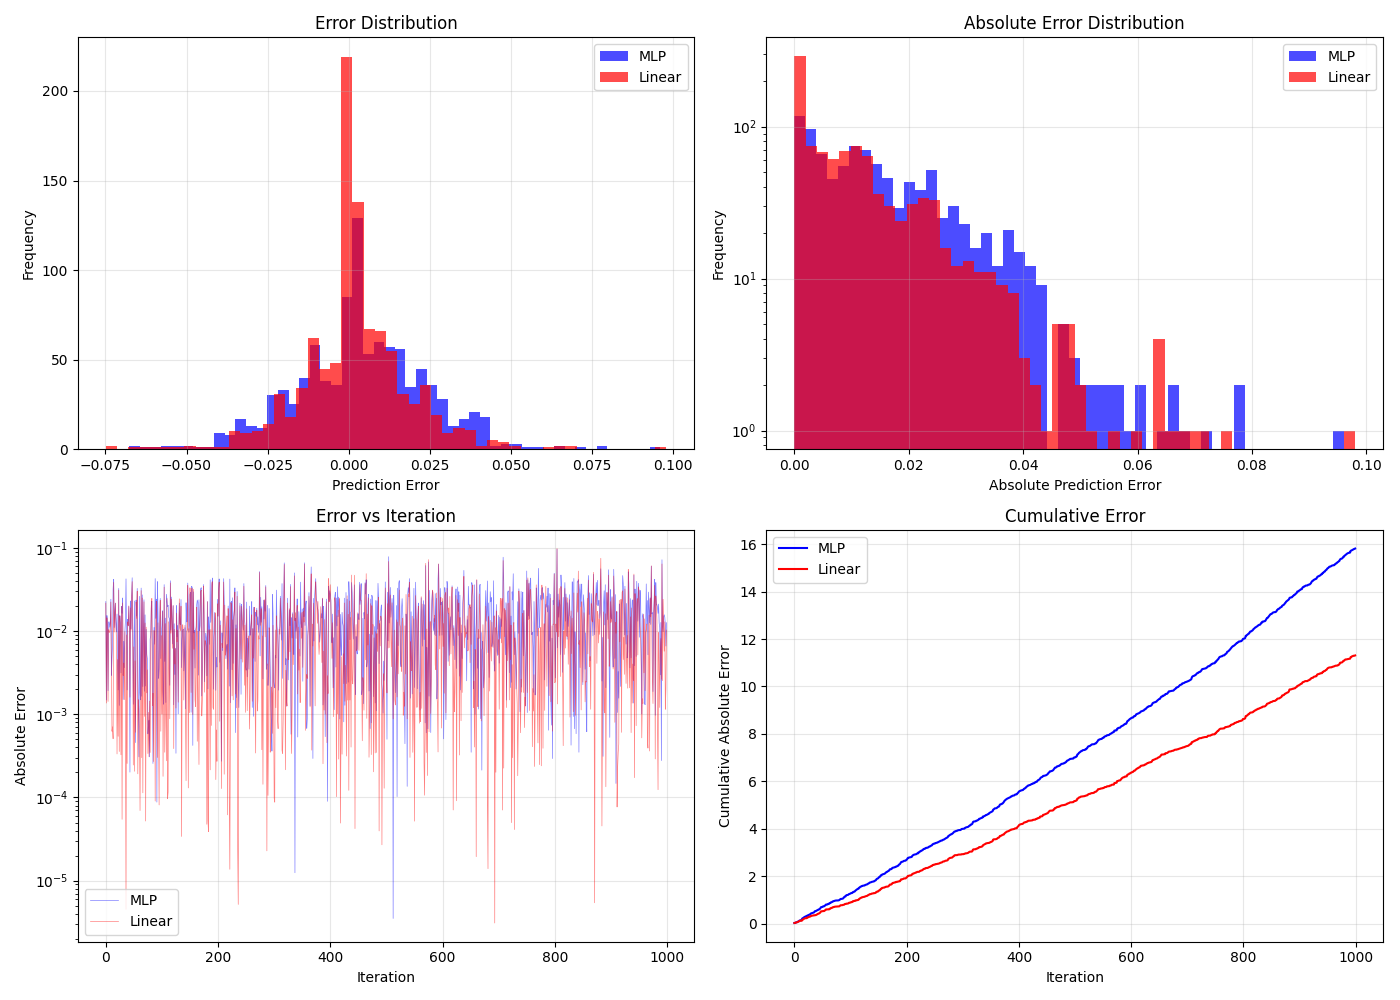

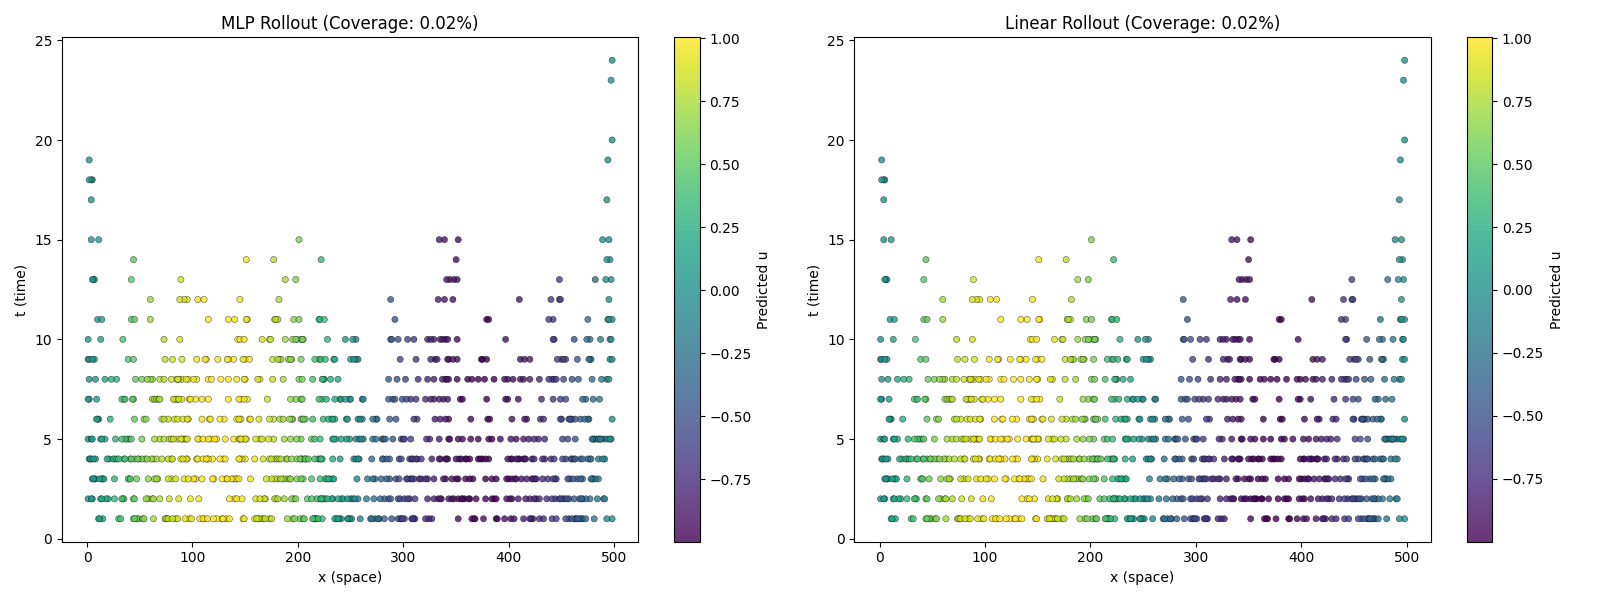

In [ ]:
# ======================
# Comparison Studies
# ======================

def compare_models(hist_mlp, hist_lin, metrics_mlp, metrics_lin):
    """
    Compare MLP and Linear models with various metrics and visualizations.
    """
    print("\n" + "="*60)
    print("MODEL COMPARISON")
    print("="*60)
    
    # Metrics comparison
    print("\n--- Coverage ---")
    print(f"MLP:    {metrics_mlp['coverage']*100:.3f}% ({metrics_mlp['iterations']} iterations)")
    print(f"Linear: {metrics_lin['coverage']*100:.3f}% ({metrics_lin['iterations']} iterations)")
    
    print("\n--- Error Metrics ---")
    print(f"MLP:    RMSE = {metrics_mlp['rmse']:.6e}, MSE = {metrics_mlp['mse']:.6e}")
    print(f"Linear: RMSE = {metrics_lin['rmse']:.6e}, MSE = {metrics_lin['mse']:.6e}")
    
    # Error distribution
    errors_mlp = np.array([h["prediction"] - h["ground_truth"] for h in hist_mlp])
    errors_lin = np.array([h["prediction"] - h["ground_truth"] for h in hist_lin])
    
    print("\n--- Error Statistics ---")
    print(f"MLP:    Mean = {np.mean(errors_mlp):.6e}, Std = {np.std(errors_mlp):.6e}, Max = {np.max(np.abs(errors_mlp)):.6e}")
    print(f"Linear: Mean = {np.mean(errors_lin):.6e}, Std = {np.std(errors_lin):.6e}, Max = {np.max(np.abs(errors_lin)):.6e}")
    
    # Visualization 1: Error comparison
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Error histograms
    axes[0, 0].hist(errors_mlp, bins=50, alpha=0.7, label='MLP', color='blue')
    axes[0, 0].hist(errors_lin, bins=50, alpha=0.7, label='Linear', color='red')
    axes[0, 0].set_xlabel('Prediction Error')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Error Distribution')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Absolute error comparison
    abs_errors_mlp = np.abs(errors_mlp)
    abs_errors_lin = np.abs(errors_lin)
    axes[0, 1].hist(abs_errors_mlp, bins=50, alpha=0.7, label='MLP', color='blue')
    axes[0, 1].hist(abs_errors_lin, bins=50, alpha=0.7, label='Linear', color='red')
    axes[0, 1].set_xlabel('Absolute Prediction Error')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Absolute Error Distribution')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_yscale('log')
    
    # Error vs iteration
    iter_mlp = np.arange(len(errors_mlp))
    iter_lin = np.arange(len(errors_lin))
    axes[1, 0].plot(iter_mlp, abs_errors_mlp, alpha=0.5, label='MLP', color='blue', linewidth=0.5)
    axes[1, 0].plot(iter_lin, abs_errors_lin, alpha=0.5, label='Linear', color='red', linewidth=0.5)
    axes[1, 0].set_xlabel('Iteration')
    axes[1, 0].set_ylabel('Absolute Error')
    axes[1, 0].set_title('Error vs Iteration')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_yscale('log')
    
    # Cumulative error comparison
    cumsum_mlp = np.cumsum(abs_errors_mlp)
    cumsum_lin = np.cumsum(abs_errors_lin)
    axes[1, 1].plot(iter_mlp, cumsum_mlp, label='MLP', color='blue')
    axes[1, 1].plot(iter_lin, cumsum_lin, label='Linear', color='red')
    axes[1, 1].set_xlabel('Iteration')
    axes[1, 1].set_ylabel('Cumulative Absolute Error')
    axes[1, 1].set_title('Cumulative Error')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Visualization 2: Side-by-side rollout comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # MLP rollout
    visited_pts_mlp = np.array(list(u_mlp.keys()))
    history_dict_mlp = {tuple(h['sampled']): h for h in hist_mlp}
    pred_pts_mlp = np.array([pt for pt in visited_pts_mlp if tuple(pt) in history_dict_mlp])
    pred_vals_mlp = np.array([u_mlp[tuple(pt)] for pt in pred_pts_mlp])
    
    if len(pred_pts_mlp) > 0:
        scatter1 = axes[0].scatter(
            pred_pts_mlp[:, 1], pred_pts_mlp[:, 0],
            c=pred_vals_mlp, s=20, cmap='viridis', alpha=0.8,
            edgecolors='black', linewidth=0.3
        )
        plt.colorbar(scatter1, ax=axes[0], label='Predicted u')
    
    axes[0].set_xlabel('x (space)')
    axes[0].set_ylabel('t (time)')
    axes[0].set_title(f'MLP Rollout (Coverage: {metrics_mlp["coverage"]*100:.2f}%)')
    axes[0].set_aspect('auto')
    
    # Linear rollout
    visited_pts_lin = np.array(list(u_lin.keys()))
    history_dict_lin = {tuple(h['sampled']): h for h in hist_lin}
    pred_pts_lin = np.array([pt for pt in visited_pts_lin if tuple(pt) in history_dict_lin])
    pred_vals_lin = np.array([u_lin[tuple(pt)] for pt in pred_pts_lin])
    
    if len(pred_pts_lin) > 0:
        scatter2 = axes[1].scatter(
            pred_pts_lin[:, 1], pred_pts_lin[:, 0],
            c=pred_vals_lin, s=20, cmap='viridis', alpha=0.8,
            edgecolors='black', linewidth=0.3
        )
        plt.colorbar(scatter2, ax=axes[1], label='Predicted u')
    
    axes[1].set_xlabel('x (space)')
    axes[1].set_ylabel('t (time)')
    axes[1].set_title(f'Linear Rollout (Coverage: {metrics_lin["coverage"]*100:.2f}%)')
    axes[1].set_aspect('auto')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'errors_mlp': errors_mlp,
        'errors_lin': errors_lin,
        'abs_errors_mlp': abs_errors_mlp,
        'abs_errors_lin': abs_errors_lin,
    }
 

C:\Users\amt35\AppData\Local\Temp\ipykernel_11260\3649486168.py:366: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


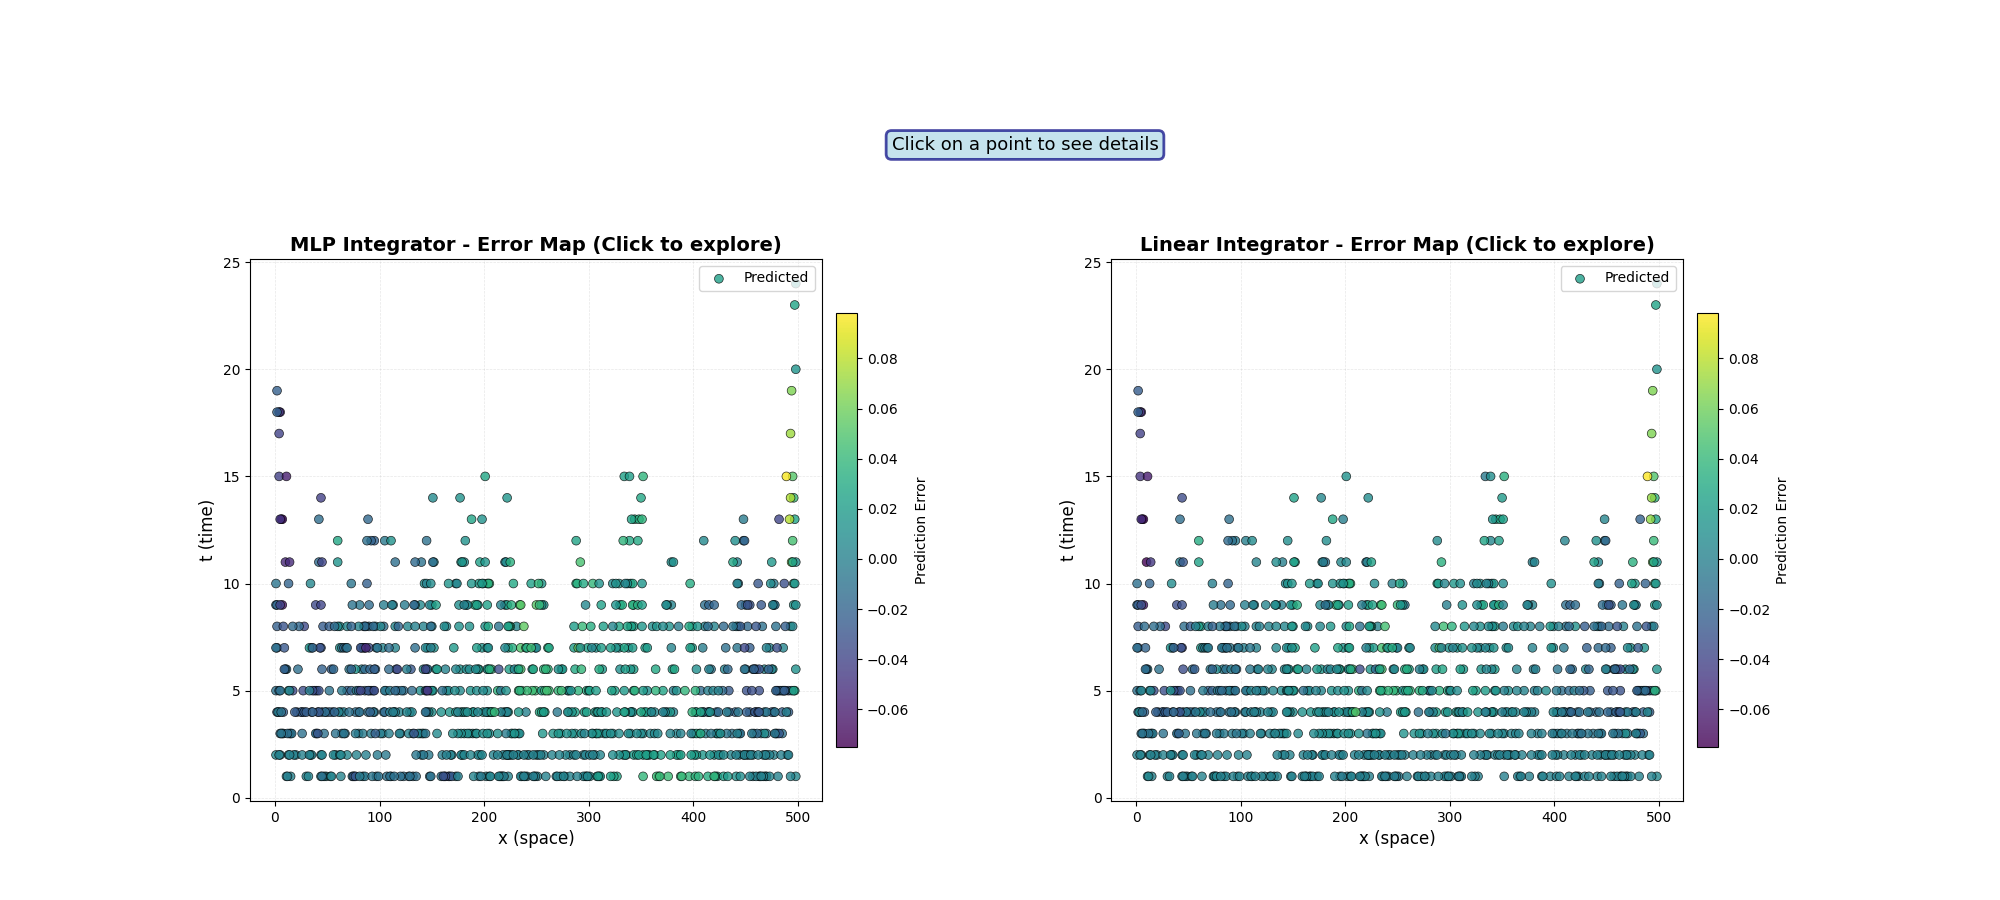


✓ Enhanced interactive comparison plot ready
  MLP:    1000 predicted points
  Linear: 1000 predicted points
  Error range: [-0.074902, 0.098057]
  Click on any point to see its neighbors and search squares!

MODEL COMPARISON

--- Coverage ---
MLP:    0.015% (1000 iterations)
Linear: 0.015% (1000 iterations)

--- Error Metrics ---
MLP:    RMSE = 2.070642e-02, MSE = 4.287556e-04
Linear: RMSE = 1.682390e-02, MSE = 2.830437e-04

--- Error Statistics ---
MLP:    Mean = 3.838466e-03, Std = 2.034753e-02, Max = 9.617532e-02
Linear: Mean = 2.076780e-03, Std = 1.669523e-02, Max = 9.805735e-02


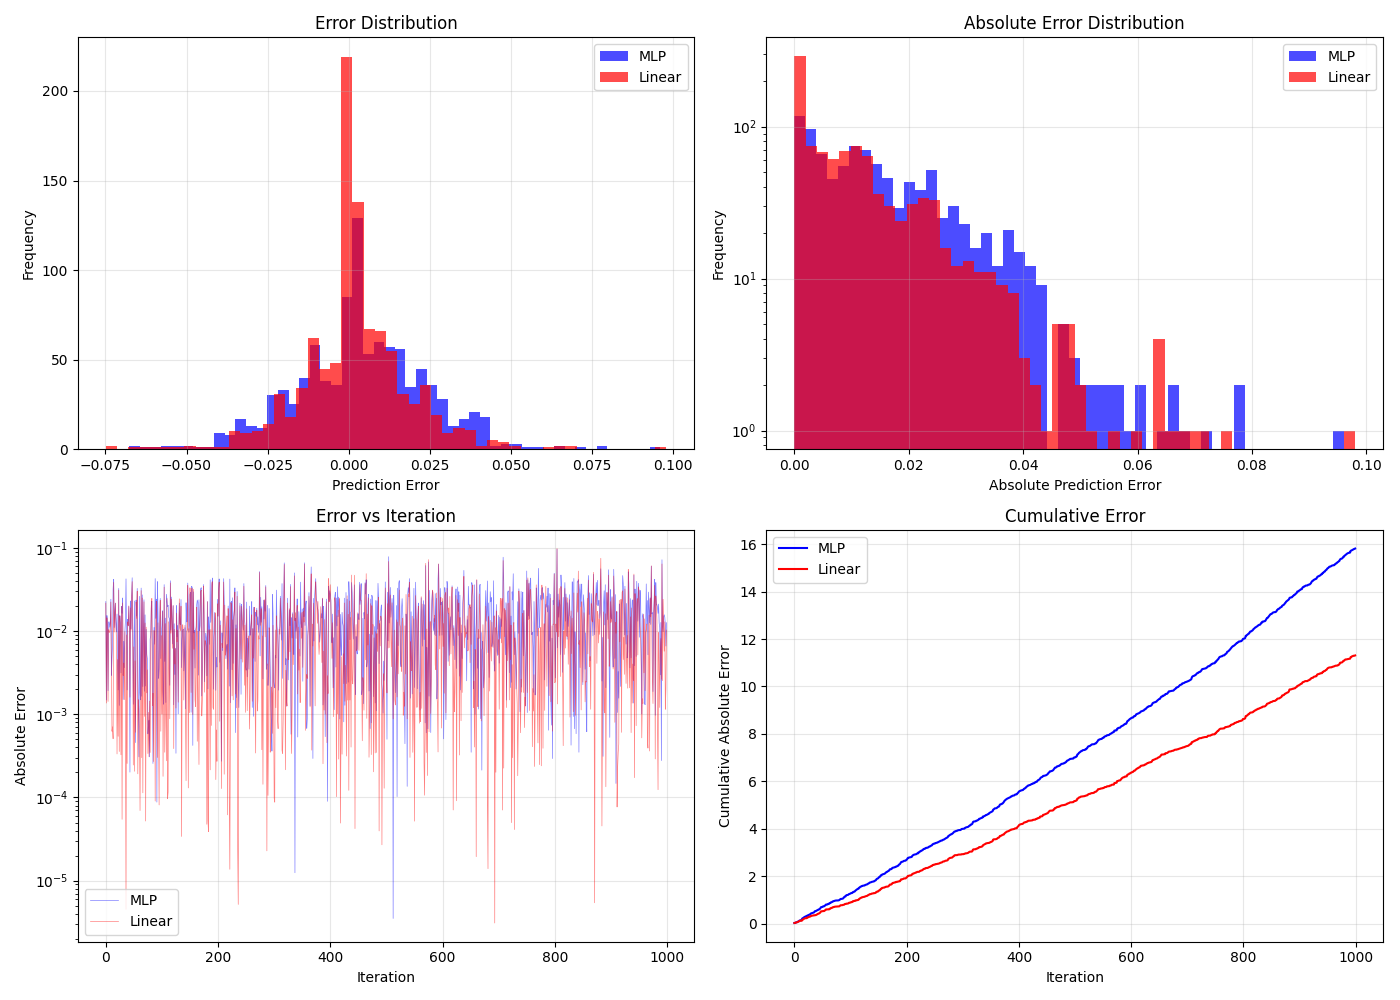

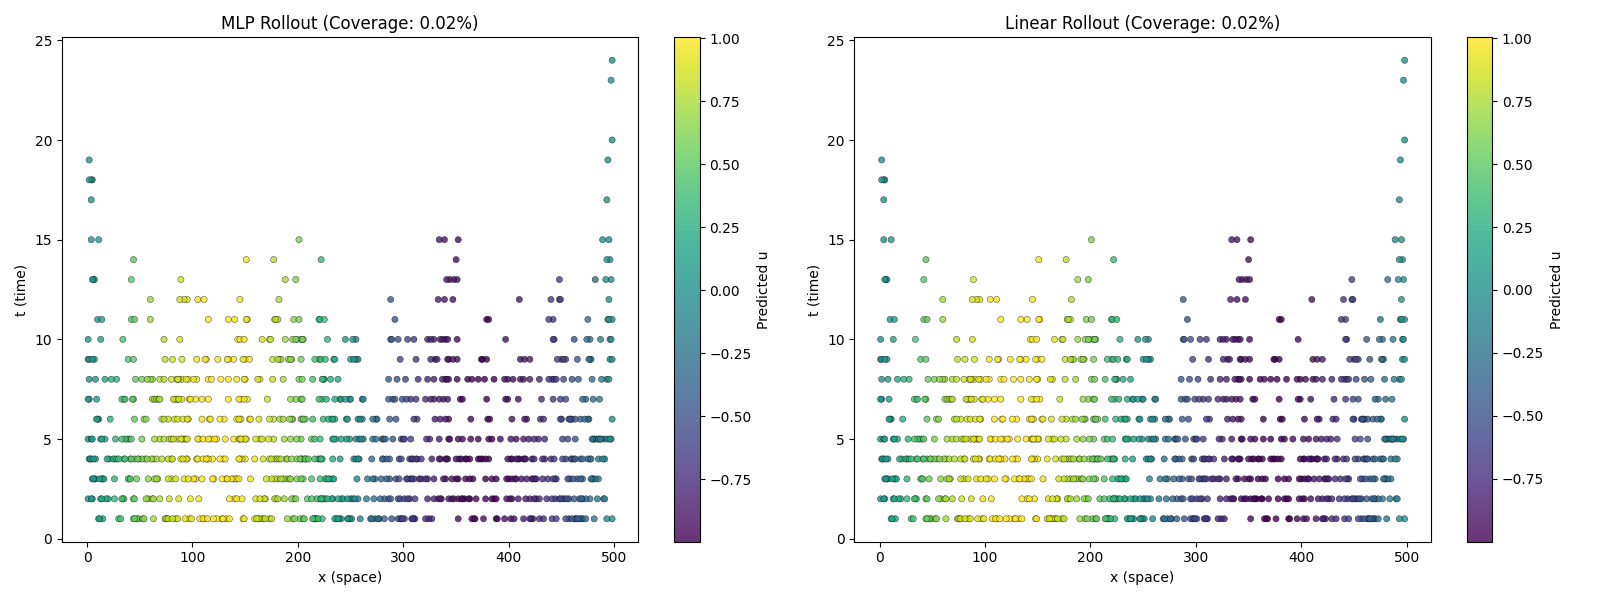

In [ ]:
_# =============================================================================
# LOAD SAVED ROLLOUT RESULTS AND RUN VISUALIZATION (no rollouts required)
# =============================================================================
# Run this cell after: imports, %matplotlib widget, the visualization
# definition cell, and the compare_models definition cell. Use this to view
# the interactive plot without re-running the MLP/Linear rollouts.

import pickle
import os

_ROLLOUT_CACHE = "rollout_results_wave.pkl"

def load_rollout_results(path=None):
    path = path or _ROLLOUT_CACHE
    with open(path, "rb") as f:
        return pickle.load(f)

loaded = load_rollout_results(_ROLLOUT_CACHE)

visited_mlp = loaded["visited_mlp"]
u_mlp = loaded["u_mlp"]
hist_mlp = loaded["hist_mlp"]
visited_lin = loaded["visited_lin"]
u_lin = loaded["u_lin"]
hist_lin = loaded["hist_lin"]
data = loaded["data"]
cfg_mlp = loaded["cfg_mlp"]
metrics_mlp = loaded["metrics_mlp"]
metrics_lin = loaded["metrics_lin"]

# Interactive click-based comparison plot
fig_click, axes_click = visualize_rollout_comparison_click_interactive(
    visited_mlp, u_mlp, hist_mlp,
    visited_lin, u_lin, hist_lin,
    data,
    Rmax=cfg_mlp["R"],
    config=cfg_mlp,
)

# Model comparison summary
comparison_results = compare_models(hist_mlp, hist_lin, metrics_mlp, metrics_lin)